In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
import os

In [2]:
db = duckdb.from_csv_auto('/Volumes/T7/IDX_data/CRMLSSold202506.csv').to_df()

In [3]:
db

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,SanDiego,SanDiego,None,False,<NA>,<NA>,False,5000.0,542181398,ops@downtowncondoguys.com,...,None,NaN,NaN,<NA>,1.0,None,92101,0.0,NaN,None
1,PacificWest,PacificWest,None,True,<NA>,<NA>,<NA>,110000.0,540760713,nowjoanne@gmail.com,...,None,355936.0,NaN,False,NaN,None,93550,0.0,355936.0,None
2,SouthwestLosAngeles,SouthwestLosAngeles,None,True,<NA>,<NA>,<NA>,1545000.0,525608302,Austin_Brown@pacificplayarealty.com,...,88x231,20212.0,NaN,False,NaN,None,90008,NaN,20212.0,None
3,TheInlandGateway,TheInlandGateway,None,True,<NA>,<NA>,False,889000.0,523319952,hutton@cbappteam.com,...,None,9600.0,0.0,True,2.0,Rim of the World,92352,0.0,9600.0,None
4,SanDiego,SanDiego,Laminate,True,<NA>,<NA>,False,1700.0,518730969,mannybehar@yahoo.com,...,None,NaN,NaN,<NA>,0.0,None,92126,0.0,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22878,Mlslistings,Mlslistings,None,False,<NA>,<NA>,<NA>,36900000.0,1019048995,btanger@intero.com,...,None,515314.8,NaN,<NA>,NaN,Other,95070,NaN,515314.8,None
22879,WestSanGabrielValley,WestSanGabrielValley,None,True,<NA>,<NA>,True,9180000.0,1018931071,sostlund@lee-assoc.com,...,None,174240.0,5.0,False,4.0,Capistrano Unified,92679,695.0,174240.0,None
22880,Mlslistings,Mlslistings,None,False,<NA>,<NA>,<NA>,349000.0,1016273554,sara@coastalcahomes.com,...,None,138521.0,NaN,<NA>,NaN,Other,93907,214.0,138521.0,None
22881,OrangeCounty,OrangeCounty,"Stone,Wood",True,<NA>,<NA>,False,17000.0,1014281750,Leeann@canadaygroup.com,...,None,5950.0,1.0,False,2.0,Laguna Beach Unified,92651,0.0,5950.0,None


In [4]:
db.describe()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,ListingKeyNumeric,...,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet
count,2.281100e+04,2.288300e+04,22883,2.288300e+04,22879.000000,22880.000000,21308.000000,2.284800e+04,22883.000000,2.288300e+04,...,22883,22443,22882,110.000000,18732.00000,2.106300e+04,12364.000000,19916.000000,15665.000000,2.104100e+04
mean,8.973742e+05,1.109938e+09,2025-06-15 05:17:54.981427,8.922487e+05,34.548733,-118.458038,1825.190867,8.619410e+05,41.476992,1.109938e+09,...,2025-06-15 05:17:54.981427,2025-05-19 17:36:26.178318,2025-04-01 02:50:59.103225,55.609091,1.37177,5.234909e+04,1.902378,1.778721,177.400540,4.638715e+05
min,0.000000e+00,4.218253e+08,2025-06-01 00:00:00,0.000000e+00,0.000000,-156.450320,0.000000,1.400000e+00,-26.000000,4.218253e+08,...,2025-06-01 00:00:00,2021-07-25 00:00:00,2015-05-15 00:00:00,0.000000,1.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,4.750000e+04,1.109110e+09,2025-06-09 00:00:00,4.000000e+04,33.733862,-118.561905,1184.000000,4.737500e+04,9.000000,1.109110e+09,...,2025-06-09 00:00:00,2025-05-09 00:00:00,2025-03-19 00:00:00,0.000000,1.00000,5.009500e+03,1.000000,1.000000,0.000000,5.227000e+03
50%,6.490000e+05,1.112153e+09,2025-06-16 00:00:00,6.315000e+05,34.041916,-118.055588,1595.000000,6.380000e+05,22.000000,1.112153e+09,...,2025-06-16 00:00:00,2025-05-22 00:00:00,2025-04-22 00:00:00,0.000000,1.00000,7.207000e+03,2.000000,2.000000,0.000000,7.405000e+03
75%,1.100000e+06,1.113861e+09,2025-06-23 00:00:00,1.100000e+06,34.393690,-117.330082,2185.250000,1.099000e+06,50.000000,1.113861e+09,...,2025-06-23 00:00:00,2025-06-04 00:00:00,2025-05-12 00:00:00,0.000000,2.00000,1.219700e+04,3.000000,2.000000,283.000000,1.361100e+04
max,2.395000e+08,1.118608e+09,2025-06-30 00:00:00,9.000000e+08,45.772309,121.116478,39111.000000,6.800000e+07,1265.000000,1.118608e+09,...,2025-06-30 00:00:00,2025-06-30 00:00:00,2025-06-30 00:00:00,2000.000000,2.00000,2.831400e+08,34.000000,500.000000,8063.000000,2.090880e+09
std,2.331296e+06,1.438173e+07,NaN,6.084893e+06,1.651760,3.917697,1164.276153,1.394472e+06,62.518260,1.438173e+07,...,NaN,NaN,NaN,252.155300,0.48329,2.020131e+06,1.435027,4.649280,340.986858,2.056782e+07


Key features:
- ListingKey is ID
- Target? OriginalListPrice or ListPrice or ClosePrice?

Issues:
- NaN values coded inconsistent
- Possible invalid values in ParkingTotal, DaysOnMarket
- ListPrice not available for 35 houses (drop or impute?)

Notes: PropertyType="Residential" and PropertySubType="SingleFamilyResidence"

In [5]:
db['PropertyType'].value_counts()

PropertyType
Residential            15329
ResidentialLease        5376
Land                     706
ManufacturedInPark       638
ResidentialIncome        571
CommercialSale           135
CommercialLease          112
BusinessOpportunity       16
Name: count, dtype: int64

# Data Ingestion

Confirmed alignment and uniqueness of key

# Missing values identification

## Populate DB with all training data

In [60]:
training_months = range(6, 13)
conn = None
conn = duckdb.connect('CRMLS.db')
path = '/Volumes/T7/IDX_data/'
files = [f for f in os.listdir(path) if not f.startswith('.')]

conn.query(
    f"""
    CREATE TABLE IF NOT EXISTS Property AS
    SELECT
        * EXCLUDE (filename),
        strptime(regexp_extract(filename, 'CRMLSSold(\\d{{6}})\\.csv$', 1), '%Y%m')::DATE AS ReadDate
    FROM read_csv_auto('/Volumes/T7/IDX_data/{files[0]}', filename = True, nullstr = ['NaN','nan','N/A','NA','', 'NULL'])
    """
)




# conn.query(
#     """
#     ALTER TABLE Property
#         ADD CONSTRAINT PK_ListingId PRIMARY KEY (ListingId, MlsStatus)
#     """
# )

for n in range(1, len(files)):
    conn.query(
        f"""
    INSERT INTO Property
    SELECT
        * EXCLUDE (filename),
        strptime(regexp_extract(filename, 'CRMLSSold(\\d{{6}})\\.csv$', 1), '%Y%m')::DATE AS ReadDate
    FROM read_csv_auto('/Volumes/T7/IDX_data/{files[n]}', filename = True, nullstr = ['NaN','nan','N/A','NA','', 'NULL'])
    """
    )


In [64]:
conn.query(
    """
    SELECT count(ListingId) FROM Property
        WHERE
            PropertyType = 'Residential' AND
            PropertySubType = 'SingleFamilyResidence'
    """
)

┌──────────────────┐
│ count(ListingId) │
│      int64       │
├──────────────────┤
│            78948 │
└──────────────────┘

In [4]:
def column_na_plot(data: pd.DataFrame):
    is_na = []
    for column in data.columns:
        is_na.append(data[column].isna().sum() * 100 / len(df[column]))
    plt.figure(figsize = (20,10))
    plt.bar(x=data.columns, height=is_na)
    plt.xticks(rotation=90)
    plt.xlabel('Columns')
    plt.ylabel('% Missing Values')
    plt.title('Percentage of Missing Values in each column')
    plt.show()

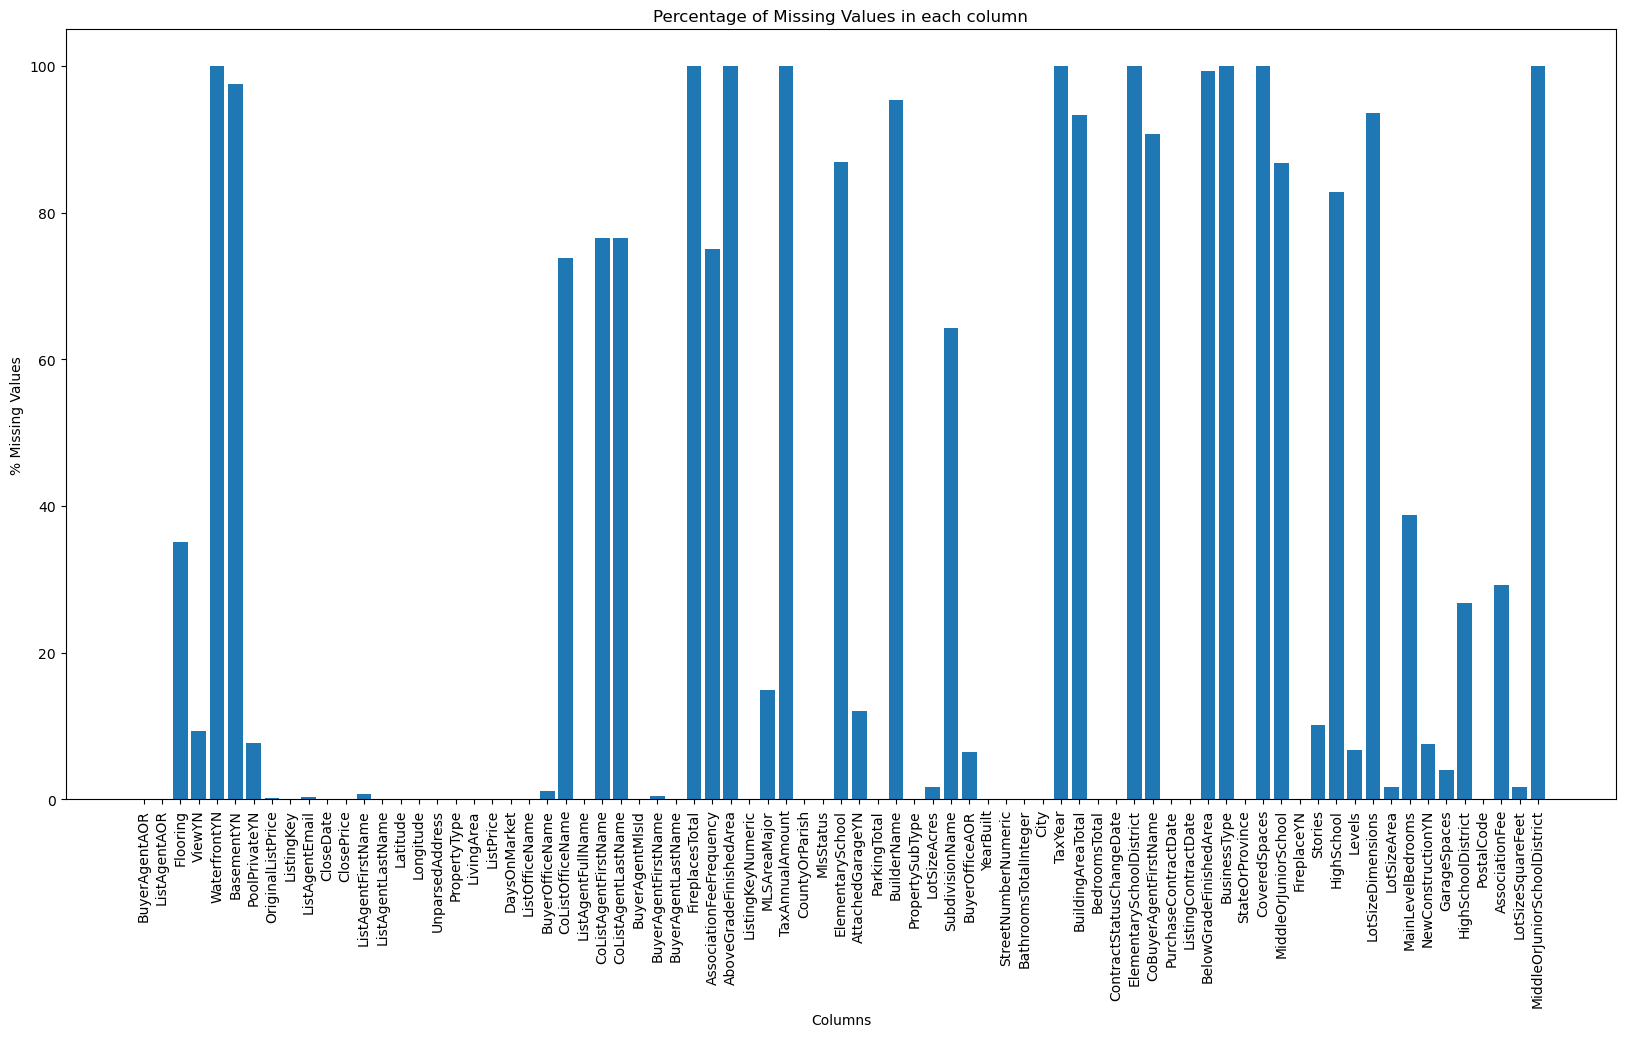

In [61]:
def reset_df():
    df = conn.query(
        """
        SELECT *
        FROM Property
        WHERE
            PropertyType = 'Residential' AND
            PropertySubType = 'SingleFamilyResidence'
        """
    ).to_df(date_as_object=True)
    df.set_index(['ListingId', 'ReadDate'], inplace=True)
    df.drop_duplicates(inplace=True)
    # df.set_index(['ListingId', 'ReadDate'], inplace=True)
    return df

df = reset_df()

column_na_plot(df)

In [62]:
df.shape

(78943, 77)

For columns with > 50% NaNs, dropping the whole columns

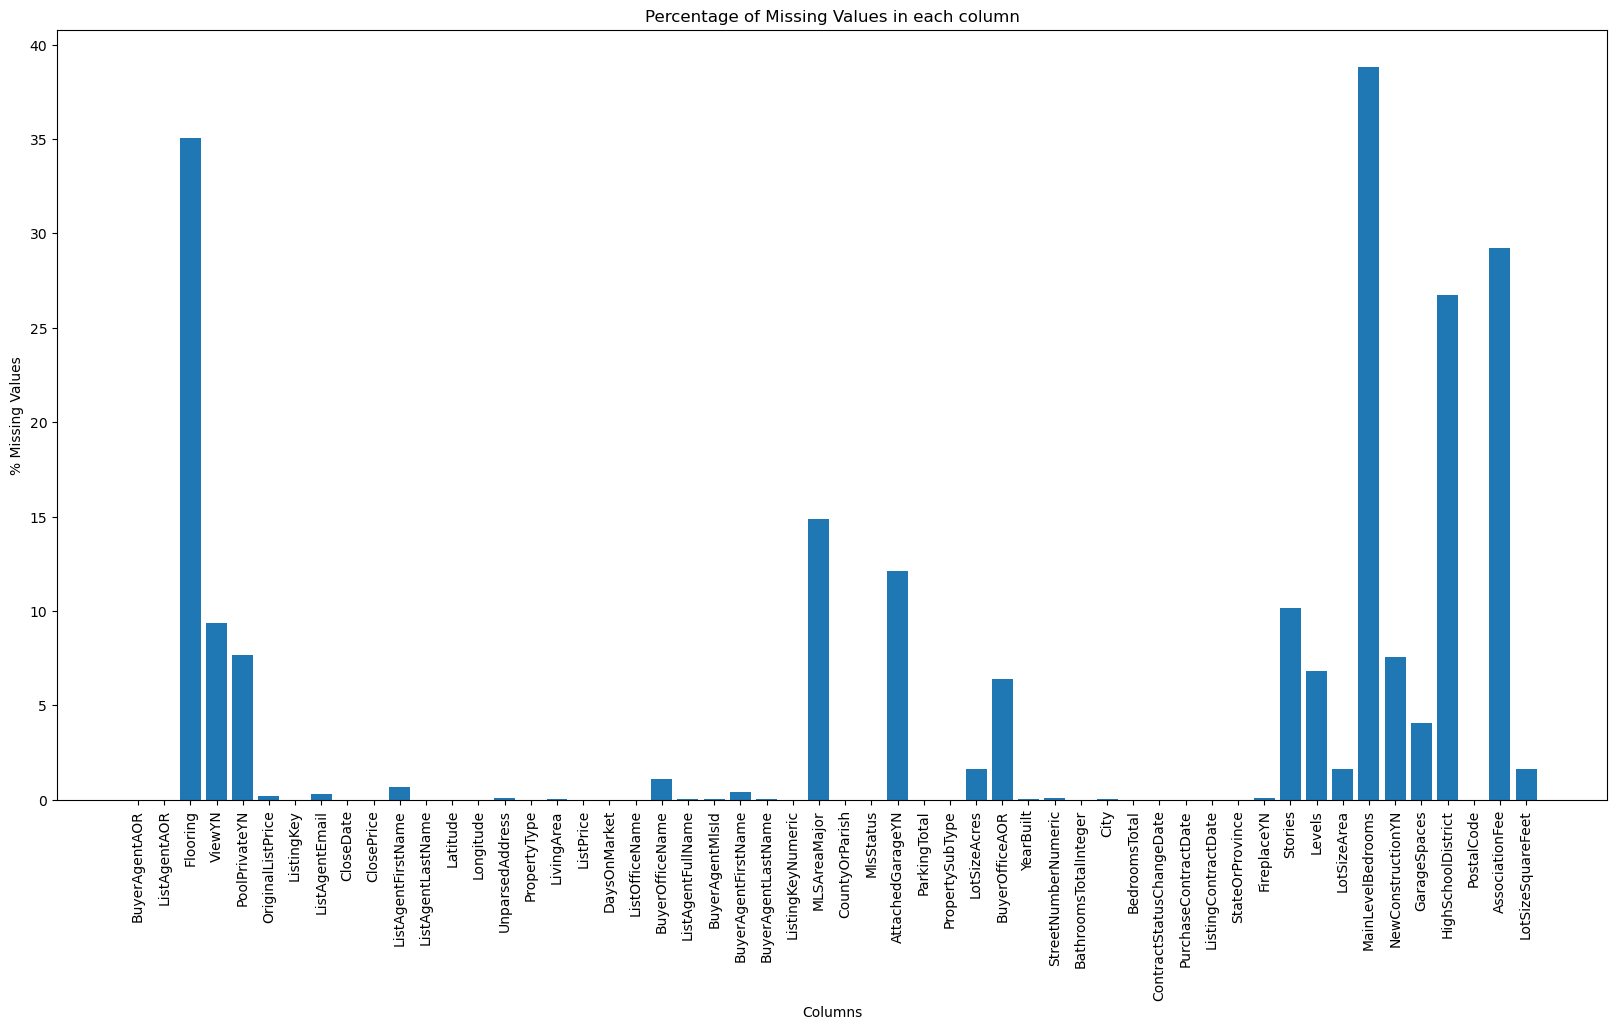

In [65]:


# column_na_plot(df)
# len(df.columns)

In [32]:
na_columns = df.columns[df.isna().sum() > 0].tolist()
print(na_columns)

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'LivingArea', 'BuyerOfficeName', 'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'MLSAreaMajor', 'AttachedGarageYN', 'ParkingTotal', 'LotSizeAcres', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'City', 'PurchaseContractDate', 'FireplaceYN', 'Stories', 'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee', 'LotSizeSquareFeet']


In [33]:
print(dropped_columns[:])

['MiddleOrJuniorSchoolDistrict', 'LotSizeDimensions', 'HighSchool', 'MiddleOrJuniorSchool', 'CoveredSpaces', 'BusinessType', 'BelowGradeFinishedArea', 'CoBuyerAgentFirstName', 'ElementarySchoolDistrict', 'BuildingAreaTotal', 'TaxYear', 'SubdivisionName', 'BuilderName', 'ElementarySchool', 'TaxAnnualAmount', 'AboveGradeFinishedArea', 'AssociationFeeFrequency', 'FireplacesTotal', 'CoListAgentLastName', 'CoListAgentFirstName', 'CoListOfficeName', 'BasementYN', 'WaterfrontYN']


## Check importance of remaining columns with NaNs

- Listing agent's name parts will be dropped and Id will be utilized to remove redundancy. However, need to compare predictive power to ListAgenAOR to see if it is needed to go in details.
- BuyerAgents information will be discarded as we can't judge people behavior based on their name.
- MainLevelBedroom is dropped due to redundancy and high missingness
- AssociationFees can be imputed with 0 to indicate the property doesn't have HOA fees.
- Drop ListingPrice and OriginalListingPrice per instructions from Aidan
- Drop ListingId fields to reduce overfit.
- Drop MLSStatus as it only contain Closed status
- Drop ListingContractDate and ContractChangeDate as the focus is in close price and DaysOnMarket already contain the necessary info.
- Drop all geographic features to remove redundancy to ZIP code


In [68]:
df = reset_df()
dropped_columns = []
is_na_count = []
i = len(is_na_count) - 1
for column in df.columns:
        is_na_count.append(df[column].isna().sum() * 100 / len(df[column]))
while i >= 0:
    na_count = is_na_count[i]
    if na_count > 50:
        dropped_columns.append(df.columns[i])
        df.drop(df.columns[i], axis=1, inplace=True)
        is_na_count.pop(i)
    i -= 1

for column in df.columns:
    if ("uyer" in column) or ("Name" in column):
        df.drop(column, axis=1, inplace=True)
df.drop(['MainLevelBedrooms', 'AssociationFee', 'ListPrice', 'OriginalListPrice', 'PropertyType', 'PropertySubType', 'ListingKey', 'ListingKeyNumeric', 'PurchaseContractDate', 'MlsStatus', 'UnparsedAddress', 'StreetNumberNumeric', 'City', 'StateOrProvince'], axis=1, inplace=True)
df.drop(['HighSchoolDistrict', 'MLSAreaMajor', 'Flooring', 'Stories', 'ListAgentEmail', 'ContractStatusChangeDate', 'ListingContractDate'], axis=1, inplace=True)
df.dropna(subset=['ClosePrice'], inplace=True)
df = df[df['ClosePrice'].between(df['ClosePrice'].quantile(0.5), df['ClosePrice'].quantile(0.95))]
df['log_price'] = np.log(df['ClosePrice'])

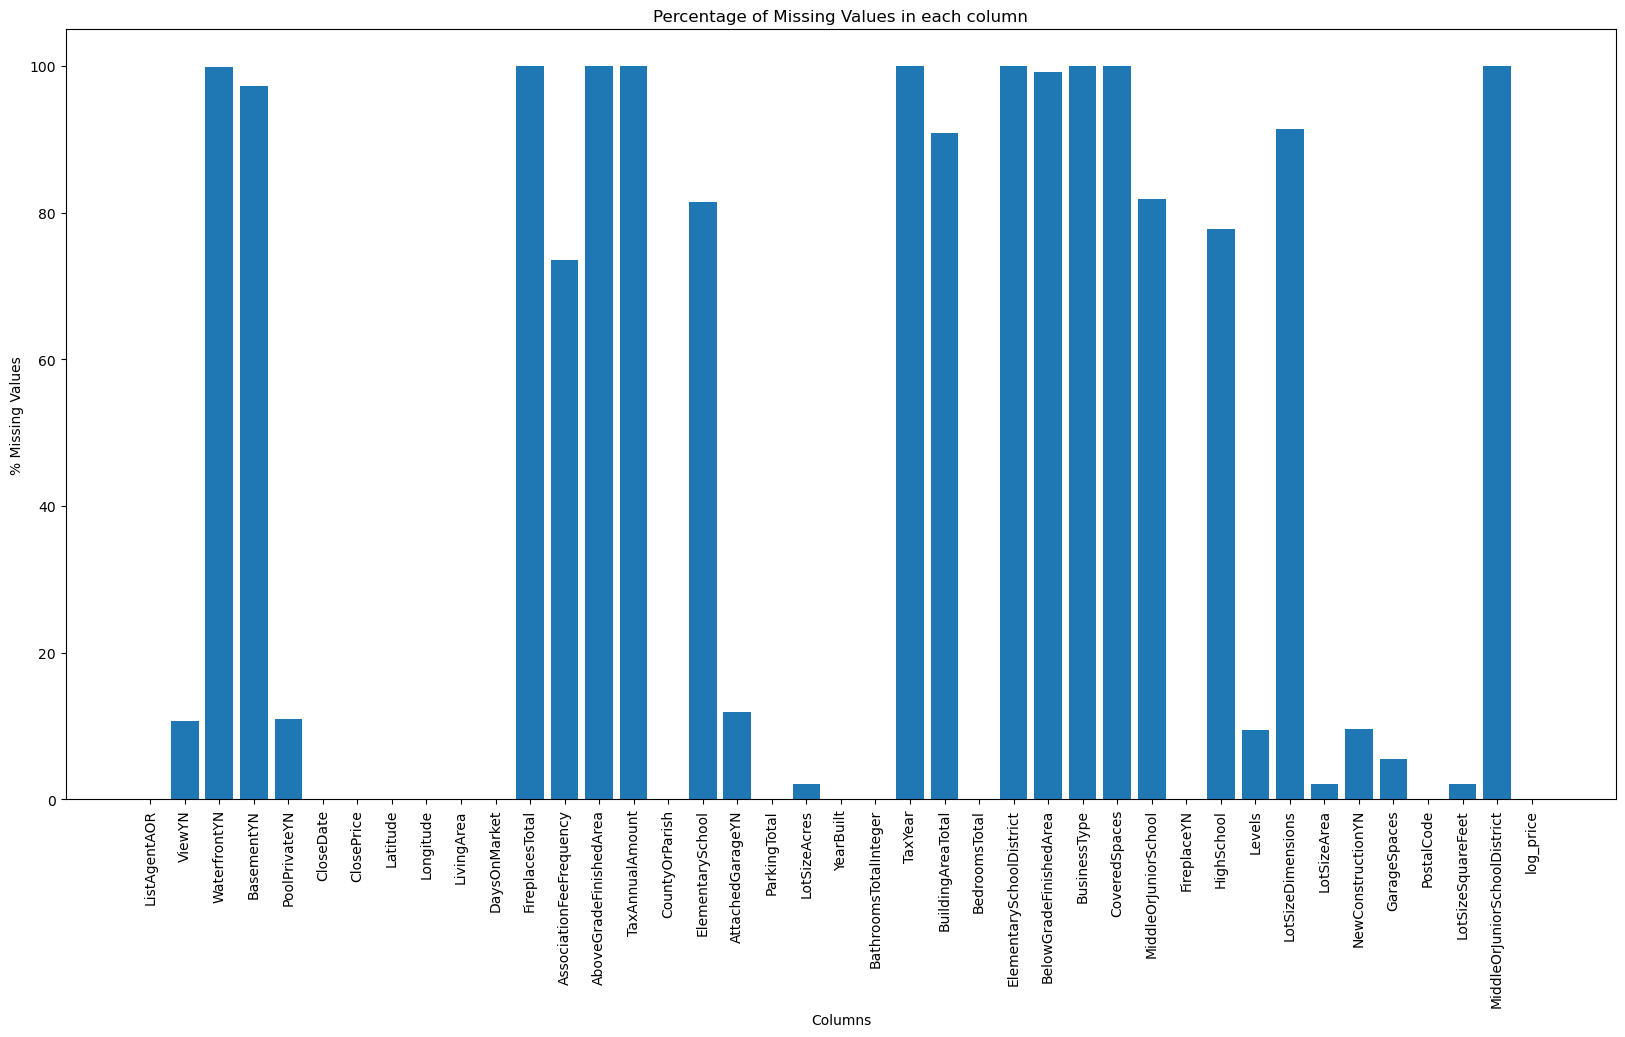

In [69]:
column_na_plot(df)

Questions:
- Is Listing agents info necessary?
- Does Zipcode alone sufficient to carry geographic info of the property or City + County + State (cannot encode quickly due to non-ordinal nature)?
- Is None in District mean property not in a school district? It has low availability, drop it?
- Should we use ContractListingDate as listing date? Is it necessary? (encode by cyclical feature)
- Should we use external inflation data?

Must imputation:
- LotSizeArea, LotSizeSquareFeet

Potential imputation:
- Levels / Stories

# Feature Engineer

In [70]:
def zipcode_parse(org: str):
    if org is not None:
        if len(org) >= 5:
            return org[:5]
        else:
            return 0
    else:
        return 0

df['PostalCode'] = df['PostalCode'].apply(zipcode_parse)

In [71]:
df.describe()

,ClosePrice,Latitude,Longitude,LivingArea,DaysOnMarket,TaxAnnualAmount,ParkingTotal,LotSizeAcres,YearBuilt,BathroomsTotalInteger,TaxYear,BuildingAreaTotal,BedroomsTotal,BelowGradeFinishedArea,LotSizeArea,GarageSpaces,LotSizeSquareFeet,log_price
count,3.565500e+04,35652.000000,35652.000000,35643.000000,35655.000000,0.0,35654.000000,34911.000000,35631.000000,35654.000000,0.0,3230.000000,35655.000000,265.000000,3.491500e+04,33687.000000,3.491300e+04,35655.000000
mean,1.483841e+06,34.696099,-118.892005,2237.598897,35.126602,NaN,3.096735,10.200119,1972.069350,2.838756,NaN,2137.447059,3.683719,51.377358,1.735953e+04,2.133553,2.518981e+05,14.154365
std,5.264381e+05,1.707074,2.568770,862.755112,43.323748,NaN,8.923044,686.329923,26.132328,1.006138,NaN,853.180865,0.919585,265.916428,1.018494e+05,3.194287,1.470834e+07,0.325667
min,8.850000e+05,0.000000,-123.821861,0.000000,-7.000000,NaN,-3.000000,0.000000,1870.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,13.693343
25%,1.070000e+06,33.718553,-120.579177,1613.000000,8.000000,NaN,2.000000,0.133100,1955.000000,2.000000,NaN,1546.000000,3.000000,0.000000,5.556500e+03,2.000000,5.800000e+03,13.883169
50%,1.330000e+06,34.064938,-118.205857,2079.000000,19.000000,NaN,2.000000,0.170000,1970.000000,3.000000,NaN,1976.000000,4.000000,0.000000,7.200000e+03,2.000000,7.405000e+03,14.100690
75%,1.750000e+06,35.190746,-117.668129,2688.000000,47.000000,NaN,4.000000,0.252900,1991.000000,3.000000,NaN,2559.000000,4.000000,0.000000,1.050000e+04,2.000000,1.101600e+04,14.375126
max,3.100000e+06,41.659796,118.390070,9874.000000,766.000000,NaN,963.000000,94090.000000,2026.000000,16.000000,NaN,8421.000000,16.000000,3437.000000,6.574511e+06,400.000000,1.938943e+09,14.946913


# Imputation

Prepare imputation for base model

In [36]:
print(f'Mean: {df['ClosePrice'].mean()}')
print(f'Stdev: {df['ClosePrice'].std()}')

Mean: 1470053.5732148534
Stdev: 519833.81195569556


In [27]:
from scipy.stats import norm

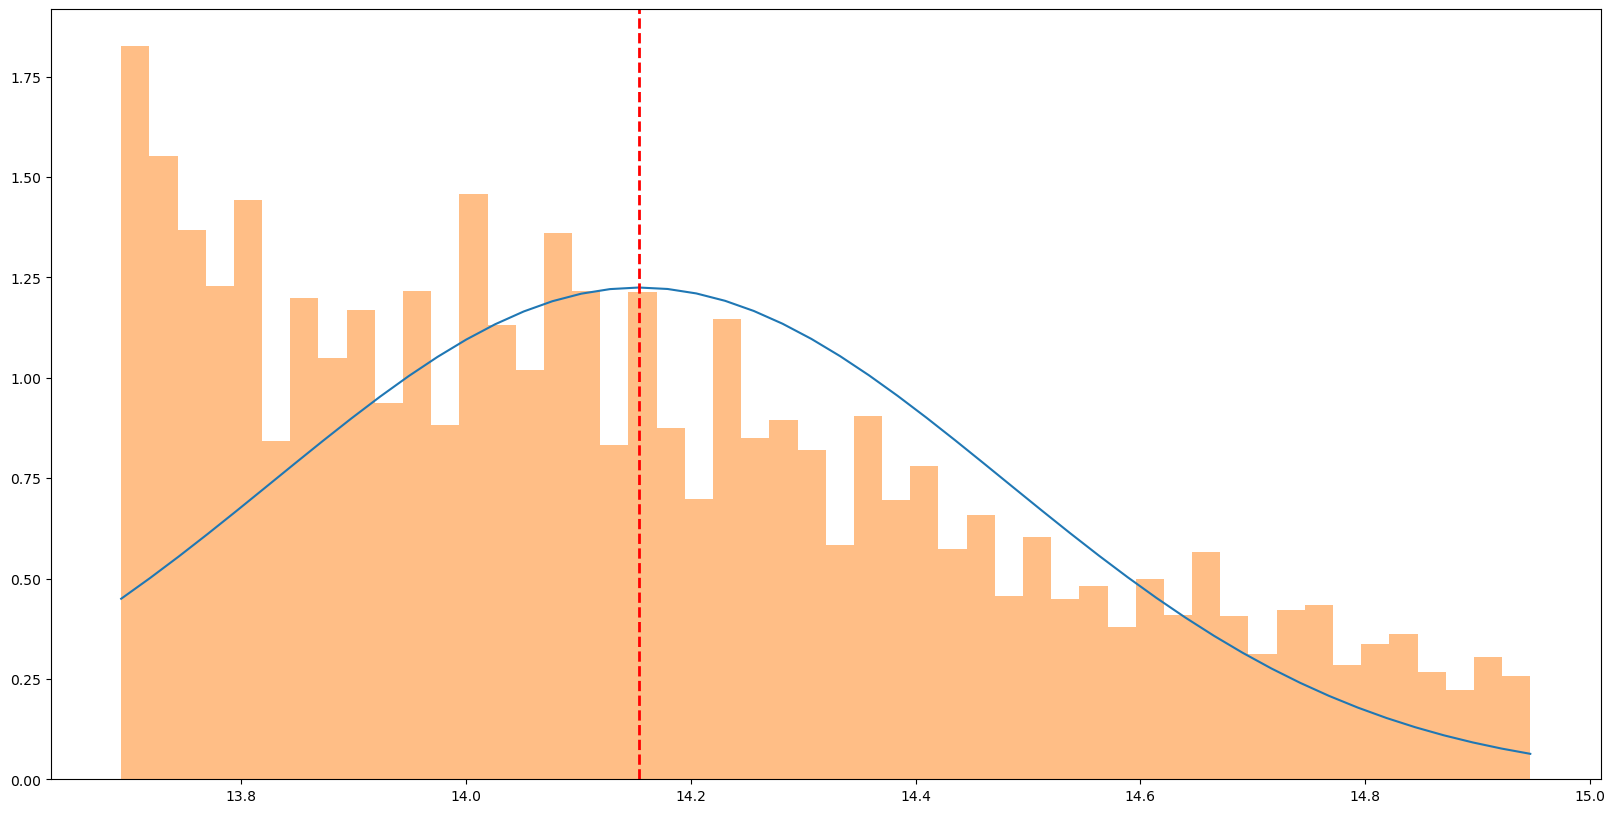

In [84]:
# Log price
# logged_price = np.log(df['ClosePrice'])
logged_price = df['log_price']

fig = plt.figure(figsize = (20,10))
domain = np.linspace(np.min(logged_price), np.max(logged_price))
mu, sigma = np.mean(logged_price), np.std(logged_price, ddof=1)
normal_curve = norm.pdf(domain, mu, sigma)
plt.plot(domain, normal_curve, label='Normal')
plt.hist(logged_price, bins=50, label='Normal', alpha=0.5, density=True)
plt.axvline(x=mu, color='r', linestyle='dashed', linewidth=2)


plt.show()

ClosePrice is Normal after logged

In [81]:
df_tmp = df.reset_index()
df_tmp['ListingId'].value_counts()

ListingId
IG25191842    2
OC25164714    2
EV21134678    1
SB25191101    1
OC25193438    1
             ..
25566803      1
41105321      1
OC25161928    1
OC25161268    1
EV24054368    1
Name: count, Length: 35653, dtype: int64

<Axes: xlabel='ClosePrice', ylabel='Count'>

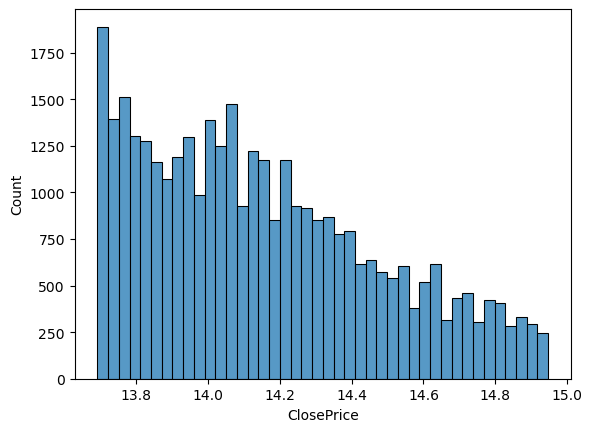

In [78]:
sns.histplot(np.log(df['ClosePrice']))

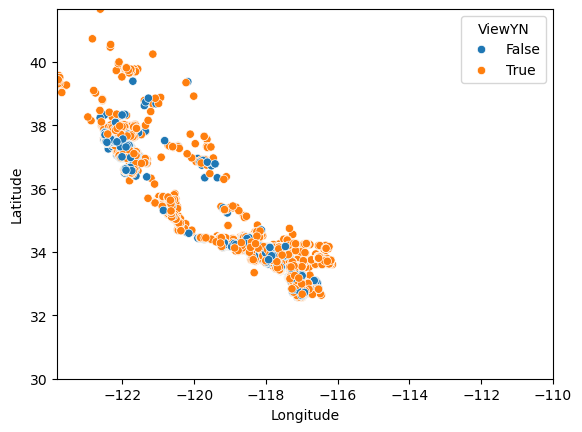

In [73]:
sns.scatterplot(
    data=df[df['ViewYN'].notnull()],
    x='Longitude',
    y='Latitude',
    hue='ViewYN',
)
plt.xlim(np.min(df['Longitude']), -110)
plt.ylim(30, np.max(df['Latitude']))

plt.show()

In [85]:
base_df = df[[column for column in df.columns if df[column].isna().sum() == 0]]
base_df

,,CloseDate,ClosePrice,DaysOnMarket,CountyOrParish,BedroomsTotal,PostalCode,log_price
ListingId,ReadDate,,,,,,,
EV21134678,2025-06-01,2025-06-13,890000.0,181,San Bernardino,3.0,92352,13.698977
25559373,2025-06-01,2025-06-30,1876384.0,87,Los Angeles,3.0,90046,14.444857
ML82012905,2025-06-01,2025-06-30,2387500.0,0,Sonoma,2.0,95476,14.685757
PW25146189,2025-06-01,2025-06-25,1775000.0,0,Los Angeles,3.0,90042,14.389311
25547507,2025-06-01,2025-06-27,1250000.0,1,Los Angeles,3.0,91401,14.038654
...,...,...,...,...,...,...,...,...
CV24179852,2025-12-01,2025-12-11,950990.0,437,San Bernardino,3.0,92336,13.765259
EV24169932,2025-12-01,2025-12-19,1562570.0,68,Los Angeles,5.0,91741,14.261842
PV24114399,2025-12-01,2025-12-17,1900000.0,511,Los Angeles,4.0,90274,14.457364


In [ ]:
base_df.info()

In [89]:
base_df['engineered_closed_date'] = base_df['CloseDate'].apply(lambda x: np.sin(2 * np.pi * (x.month/12.0)))

/tmp/ipykernel_83891/510315463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_df['engineered_closed_date'] = base_df['CloseDate'].apply(lambda x: np.sin(2 * np.pi * (x.month/12.0)))


In [98]:
base_df = pd.get_dummies(base_df, columns=['CountyOrParish'])

In [103]:
y = base_df['ClosePrice']
base_df.drop('ClosePrice', axis=1, inplace=True)

In [101]:
base_df.reset_index(inplace=True)
base_df.drop(columns=['ReadDate', 'CloseDate', 'ListingId'], axis=1, inplace=True)

In [112]:
X_train, X_test, y_train, y_test = train_test_split(base_df, y, test_size=0.2, random_state=42)

# Linear Regression

In [115]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9716340798445401

In [118]:
y_predicted = model.predict(X_test)
error = np.pow((y_predicted - y_test), 2)


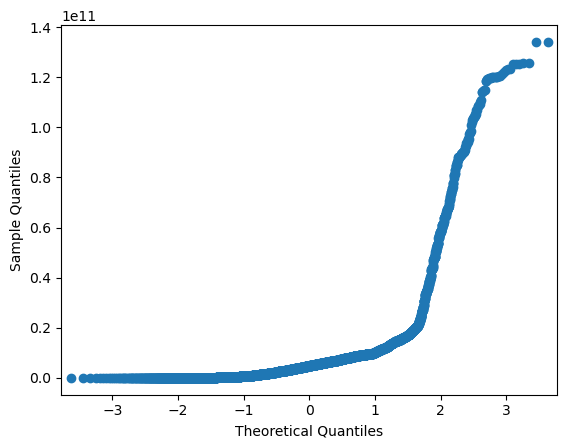

In [122]:
from statsmodels.graphics.gofplots import qqplot

qqplot(error, ax=plt.gca())
plt.show()

## Conclusion

- Error not normally distributed. Cannot proceed with Linear Regression

In [125]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
error = np.pow((y_predicted - y_test), 2)
model.score(X_test, y_test)

0.9999999159018419

In [128]:
from sklearn.model_selection import cross_val_score
import sklearn.metrics

scores = cross_val_score(model, X_train, y_train, cv=10, scoring='neg_mean_squared_error')

In [129]:
scores

array([-36367.86931224, -37664.35300529, -23876.68900011, -26840.83836146,
       -24831.818834  , -21260.77150723, -37840.11293852, -27198.34791448,
       -27078.86048681, -32187.39186941])

In [130]:
np.mean(scores)

np.float64(-29514.70532295454)

By using non-NA features and encoded county information, I achieved a model that can predict with R2 = 0.99 and average MSE of 29,514$